In [8]:
# Step 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Feature selection (RFE - as in paper)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Class balancing (SMOTE - as in paper)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models (as in paper, adapted)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC  # Added for your request

# Evaluation metrics
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                           recall_score, roc_auc_score, classification_report,
                           confusion_matrix, roc_curve)

# For SHAP analysis (as in paper)
import shap

print("All libraries imported successfully!")


All libraries imported successfully!


c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# ================================================================
# WHY THIS STEP: Raw data always has issues that break ML models
# ================================================================

# Load your data
df = pd.read_csv('../women_autonomy_regression/outputs/recoded_analysis_data.csv')
print(f"Original shape: {df.shape}")  # Check how many rows/columns

# -----------------------------------------------------------------
# 2.1: Drop useless columns
# -----------------------------------------------------------------
# WHY: These columns don't help predict the target
#   - weight: Sampling weight (use for descriptive stats only, not ML)
#   - cluster_id: Just an ID number (random, no predictive power)
#   - age_group: Redundant with age (age gives more detail)
#   - children_group: Redundant with num_children
#   - anc_visits: Too many missing values (use anc_group instead)

drop_cols = ['weight', 'cluster_id', 'age_group', 'children_group', 'anc_visits']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])
print(f"After dropping columns: {df.shape}")

# -----------------------------------------------------------------
# 2.2: Remove invalid target values
# -----------------------------------------------------------------
# WHY: '6' = 'Other' - only 2 rows (0.1% of data)
#      Keeping them would confuse the model (too few examples to learn from)

print(f"Target values before: {df['fp_decision_autonomy'].unique()}")
df = df[df['fp_decision_autonomy'] != 6]
print(f"Target values after: {df['fp_decision_autonomy'].unique()}")

# -----------------------------------------------------------------
# 2.3: Handle missing values
# -----------------------------------------------------------------
# WHY: ML models cannot process NaN/None values
#      Strategy: median for numbers, mode (most common) for categories
#      This matches what Melaku et al. did

# Create imputers
numeric_imputer = SimpleImputer(strategy='median')   # For age, num_children
categorical_imputer = SimpleImputer(strategy='most_frequent')  # For everything else

NUMERICAL_FEATURES = ["age","num_children"]
CATEGORICAL_FEATURES = ["residence","edu_woman","religion","region","marital_status",
                        "wealth","marriage_type",
                        "woman_working","fertility_preference","current_method",
                        "husband_working","husband_desired_children","anc_group",
                        "fieldworker_fp","facility_fp","media_any"]

# Apply to each column
# Apply to your data
for col in CATEGORICAL_FEATURES:
    if df[col].isnull().any():
        df[col] = categorical_imputer.fit_transform(df[[col]]).ravel()

for col in NUMERICAL_FEATURES:
    if df[col].isnull().any():
        df[col] = numeric_imputer.fit_transform(df[[col]]).ravel()

print("Missing values handled")

# -----------------------------------------------------------------
# 2.4: Special handling for edu_husband (8 = Don't Know)
# -----------------------------------------------------------------
# WHY: 8 is a valid category, not a true missing value
#      But it should be treated as a separate category

df['edu_husband'] = df['edu_husband'].replace(8, np.nan)
df['edu_husband'] = df['edu_husband'].fillna(df['edu_husband'].mode()[0])
print("edu_husband: 'Don't Know' (8) converted to NaN then mode")


Original shape: (1533, 25)
After dropping columns: (1533, 20)
Target values before: [2. 3. 1. 6.]
Target values after: [2. 3. 1.]
Missing values handled
edu_husband: 'Don't Know' (8) converted to NaN then mode


In [11]:
# ================================================================
# WHY THIS STEP: Outliers can distort model training
#   - Extreme values pull decision boundaries in wrong direction
#   - Some outliers are data entry errors
#   - Paper used 5% contamination (expect 5% of data to be outliers)
# ================================================================

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import OrdinalEncoder

print("\n" + "="*60)
print("OUTLIER DETECTION - Local Outlier Factor (LOF)")
print("="*60)

# -----------------------------------------------------------------
# 3.1: Prepare data for LOF
# -----------------------------------------------------------------
# WHY: LOF needs numerical input, but we have categorical variables
#      OrdinalEncoder temporarily converts categories to numbers for detection only

# Prepare feature lists
NUMERICAL = ['age', 'num_children']
CATEGORICAL = [col for col in df.columns if col not in NUMERICAL + ['fp_decision_autonomy']]

# Create temporary numeric version for LOF
temp_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_temp = temp_encoder.fit_transform(df[NUMERICAL + CATEGORICAL])

# -----------------------------------------------------------------
# 3.2: Apply LOF
# -----------------------------------------------------------------
# WHY: contamination=0.05 means "expect 5% of data to be outliers"
#      This matches the paper's methodology

lof = LocalOutlierFactor(contamination=0.05)
outlier_labels = lof.fit_predict(X_temp)

# outlier_labels = 1 for normal, -1 for outlier
outlier_count = (outlier_labels == -1).sum()
print(f"Outliers detected: {outlier_count} ({outlier_count/len(df)*100:.1f}%)")

# -----------------------------------------------------------------
# 3.3: Remove outliers
# -----------------------------------------------------------------
# WHY: We want clean data for training
#      Removing 5% of data is acceptable

df_clean = df[outlier_labels == 1].copy()
print(f"Shape after outlier removal: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")


OUTLIER DETECTION - Local Outlier Factor (LOF)
Outliers detected: 77 (5.0%)
Shape after outlier removal: (1454, 20)
Rows removed: 77


In [12]:
# ================================================================
# WHY EDA: You must understand your data BEFORE modeling
#   - Find class imbalance (need balancing?)
#   - Check for constant features (useless for prediction)
#   - Calculate weighted statistics (for reporting)
# ================================================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# -----------------------------------------------------------------
# 4.1: Target distribution (CRITICAL!)
# -----------------------------------------------------------------
# WHY: If one class has very few samples, model will ignore it
#      Need to know if balancing is required

print("\n--- Target Distribution ---")
target_counts = df_clean['fp_decision_autonomy'].value_counts()
target_pct = df_clean['fp_decision_autonomy'].value_counts(normalize=True) * 100

for val in [1, 2, 3]:
    if val in target_counts:
        labels = {1: '1 = Woman alone', 2: '2 = Partner alone', 3: '3 = Joint decision'}
        print(f"{labels[val]}: {target_counts[val]} ({target_pct[val]:.1f}%)")

# Rule of thumb: If smallest class < 15%, use balancing
min_pct = target_pct.min()
if min_pct < 15:
    print(f"\n⚠️ Smallest class has only {min_pct:.1f}% - WILL USE SMOTE BALANCING")
    USE_SMOTE = True
else:
    print(f"\n✓ Classes reasonably balanced - SMOTE optional")
    USE_SMOTE = False

# -----------------------------------------------------------------
# 4.2: Weighted descriptive statistics (for your report)
# -----------------------------------------------------------------
# WHY: Paper used weights for population-representative estimates
#      Only for reporting, NOT for model training

print("\n--- Weighted Statistics (For Reporting Only) ---")

# If you saved the weight column earlier, use it
if 'weight' in df.columns:
    # Weighted target distribution
    weighted_target = (df.groupby('fp_decision_autonomy')['weight'].sum() / 
                       df['weight'].sum() * 100)
    print("Weighted target distribution:")
    print(weighted_target.round(1))
else:
    print("Weight column not available - using unweighted statistics")

# -----------------------------------------------------------------
# 4.3: Check for constant/near-constant features
# -----------------------------------------------------------------
# WHY: If 95%+ of values are the same, feature has no predictive power

print("\n--- Checking for Constant Features ---")
for col in df_clean.columns:
    if col != 'fp_decision_autonomy':
        most_common_pct = df_clean[col].value_counts(normalize=True).iloc[0] * 100
        if most_common_pct > 95:
            print(f"⚠️ {col}: {most_common_pct:.1f}% in one category - consider dropping")


EXPLORATORY DATA ANALYSIS (EDA)

--- Target Distribution ---
1 = Woman alone: 394 (27.1%)
2 = Partner alone: 228 (15.7%)
3 = Joint decision: 832 (57.2%)

✓ Classes reasonably balanced - SMOTE optional

--- Weighted Statistics (For Reporting Only) ---
Weight column not available - using unweighted statistics

--- Checking for Constant Features ---
⚠️ husband_working: 98.4% in one category - consider dropping


In [13]:
# ================================================================
# WHY THIS IS CRITICAL: You must tell the computer which is which!
# 
# The computer sees: religion = [1, 2, 4, 1, 3]
# If you don't specify, it thinks: "4 is bigger than 2"
# But that's WRONG - 4 is just a different religion, not "more" religion
# ================================================================

print("\n" + "="*60)
print("FEATURE CLASSIFICATION (Numerical vs Categorical)")
print("="*60)

# -----------------------------------------------------------------
# 5.1: Numerical features (true numbers with meaning)
# -----------------------------------------------------------------
# WHY: These represent actual quantities where order and distance matter
#      age: 20 years old is truly 10 years more than 10 years old
#      num_children: 4 children is truly twice as many as 2 children

NUMERICAL_FEATURES = ['age', 'num_children']

print(f"\nNumerical features ({len(NUMERICAL_FEATURES)}):")
for f in NUMERICAL_FEATURES:
    print(f"  - {f}: true numeric value (no encoding needed, just scale)")

# -----------------------------------------------------------------
# 5.2: Categorical features (numbers are just labels)
# -----------------------------------------------------------------
# WHY: The number is arbitrary - just an ID for a category
#      religion 4 is NOT "greater than" religion 1
#      residence 2 (Rural) is NOT "greater than" residence 1 (Urban)

CATEGORICAL_FEATURES = [
    'edu_woman', 'edu_husband', 'wealth', 'residence', 'region', 'religion',
    'marital_status', 'marriage_type', 'current_method', 'fertility_preference',
    'woman_working', 'husband_working', 'fieldworker_fp', 'facility_fp',
    'media_any', 'anc_group'
]

# Only keep features that exist in your data
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df_clean.columns]

print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}):")
for f in CATEGORICAL_FEATURES:
    unique_vals = df_clean[f].nunique()
    print(f"  - {f}: {unique_vals} unique values (will become {unique_vals} columns after one-hot)")

# -----------------------------------------------------------------
# 5.3: Target variable
# -----------------------------------------------------------------
TARGET = 'fp_decision_autonomy'

# Convert target to 0,1,2 for model compatibility
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df_clean[TARGET])
print(f"\nTarget encoded: {dict(zip(le.classes_, range(len(le.classes_))))}")


FEATURE CLASSIFICATION (Numerical vs Categorical)

Numerical features (2):
  - age: true numeric value (no encoding needed, just scale)
  - num_children: true numeric value (no encoding needed, just scale)

Categorical features (16):
  - edu_woman: 4 unique values (will become 4 columns after one-hot)
  - edu_husband: 4 unique values (will become 4 columns after one-hot)
  - wealth: 5 unique values (will become 5 columns after one-hot)
  - residence: 2 unique values (will become 2 columns after one-hot)
  - region: 12 unique values (will become 12 columns after one-hot)
  - religion: 6 unique values (will become 6 columns after one-hot)
  - marital_status: 2 unique values (will become 2 columns after one-hot)
  - marriage_type: 3 unique values (will become 3 columns after one-hot)
  - current_method: 2 unique values (will become 2 columns after one-hot)
  - fertility_preference: 3 unique values (will become 3 columns after one-hot)
  - woman_working: 2 unique values (will become 2 col

In [14]:
# ================================================================
# WHY SPLIT: To get honest performance estimate
#
# If you train and test on same data: Model just memorizes (overfitting)
# Like a student taking the same test they studied from - not real learning
#
# 80/20 split: 
#   - 80% training: Model learns patterns
#   - 20% test: Model sees NEW data (like real world)
#   - Test set used ONLY ONCE at end
# ================================================================

print("\n" + "="*60)
print("TRAIN/TEST SPLIT (80/20)")
print("="*60)

# Prepare features
X = df_clean[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]

# stratify=y ensures same class distribution in both train and test
# random_state=42 makes results reproducible (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,      # 20% for testing
    random_state=42,     # Reproducible results
    stratify=y           # Preserves class balance
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify stratification worked
print("\nTraining target distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("Test target distribution:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

# CRITICAL: Test set is now OFF LIMITS until final evaluation
print("\n⚠️ TEST SET IS NOW SEALED - Do not touch until final evaluation!")


TRAIN/TEST SPLIT (80/20)
Training set: 1163 samples (80%)
Test set: 291 samples (20%)

Training target distribution:
2    0.573
0    0.271
1    0.156
Name: proportion, dtype: float64
Test target distribution:
2    0.570
0    0.271
1    0.158
Name: proportion, dtype: float64

⚠️ TEST SET IS NOW SEALED - Do not touch until final evaluation!


In [15]:
# ================================================================
# WHY PREPROCESSING: Models only understand numbers, but different types
#                    need different treatment
#
# Pipeline ensures:
#   1. Same preprocessing applied to train AND test
#   2. No data leakage (test data never influences preprocessing)
#   3. Reproducible workflow
# ================================================================

print("\n" + "="*60)
print("CREATING PREPROCESSING PIPELINE")
print("="*60)

# -----------------------------------------------------------------
# 7.1: Numerical pipeline
# -----------------------------------------------------------------
# WHY: StandardScaler transforms data to mean=0, standard deviation=1
#      This is CRITICAL for SVM (distance-based algorithm)
#      Also helps tree models converge faster

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing with median
    ('scaler', StandardScaler())                    # Transform to mean=0, std=1
])

print("Numerical pipeline:")
print("  - Step 1: Fill missing values with median")
print("  - Step 2: Scale to mean=0, std=1")

# -----------------------------------------------------------------
# 7.2: Categorical pipeline
# -----------------------------------------------------------------
# WHY: OneHotEncoder creates a new 0/1 column for EACH category
#      Example: religion (1,2,4) becomes columns:
#        religion_1, religion_2, religion_4
#      Each column = 1 if that category, else 0
#      handle_unknown='ignore' = if new category appears in test, set all to 0

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("\nCategorical pipeline:")
print("  - Step 1: Fill missing values with most common value")
print("  - Step 2: One-hot encode (create 0/1 columns for each category)")

# -----------------------------------------------------------------
# 7.3: Combine into ColumnTransformer
# -----------------------------------------------------------------
# WHY: Applies different pipelines to different column types

preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, NUMERICAL_FEATURES),
    ('categorical', categorical_pipeline, CATEGORICAL_FEATURES)
])

print("\nColumnTransformer combines both pipelines:")
print(f"  - Numerical columns: {NUMERICAL_FEATURES}")
print(f"  - Categorical columns: {CATEGORICAL_FEATURES}")

# Test the preprocessor
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)

print(f"\nBefore preprocessing: {X_train.shape[1]} features")
print(f"After preprocessing: {X_train_processed.shape[1]} features")


CREATING PREPROCESSING PIPELINE
Numerical pipeline:
  - Step 1: Fill missing values with median
  - Step 2: Scale to mean=0, std=1

Categorical pipeline:
  - Step 1: Fill missing values with most common value
  - Step 2: One-hot encode (create 0/1 columns for each category)

ColumnTransformer combines both pipelines:
  - Numerical columns: ['age', 'num_children']
  - Categorical columns: ['edu_woman', 'edu_husband', 'wealth', 'residence', 'region', 'religion', 'marital_status', 'marriage_type', 'current_method', 'fertility_preference', 'woman_working', 'husband_working', 'fieldworker_fp', 'facility_fp', 'media_any', 'anc_group']

Before preprocessing: 18 features
After preprocessing: 62 features


In [16]:
# ================================================================
# WHY SMOTE: When classes are imbalanced, model learns to predict
#            majority class and ignore minority class
#
# HOW SMOTE WORKS: 
#   1. Pick a minority class sample
#   2. Find its k nearest neighbors
#   3. Create synthetic sample along line between them
#   4. Repeat until classes balanced
#
# CRITICAL: SMOTE applied ONLY to training data, NEVER to test set!
# ================================================================

print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*60)

if USE_SMOTE:
    print("SMOTE will be applied to balance classes")
    print("Before SMOTE (training set):")
    print(pd.Series(y_train).value_counts().to_string())
    
    # SMOTE creates synthetic samples
    # sampling_strategy='auto' balances to equal number per class
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    
    # For illustration (will be inside pipeline for actual training)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)
    
    print("\nAfter SMOTE (training set):")
    print(pd.Series(y_train_balanced).value_counts().to_string())
    
    print("\n✓ Classes now balanced!")
else:
    print("No SMOTE needed - classes are reasonably balanced")


HANDLING CLASS IMBALANCE WITH SMOTE
No SMOTE needed - classes are reasonably balanced


In [17]:
# ================================================================
# WHY MULTIPLE MODELS: No single model is best for all problems
#   - Each model has different strengths/weaknesses
#   - We let the data DECIDE which works best
#   - Paper found LightGBM best, but YOUR data might prefer different
# ================================================================

print("\n" + "="*60)
print("DEFINING 7 MODELS (Following Paper)")
print("="*60)

# -----------------------------------------------------------------
# Helper: Create pipeline with preprocessing + SMOTE + model
# -----------------------------------------------------------------

def create_model_pipeline(model):
    """Wraps preprocessor, SMOTE, and model in single pipeline"""
    if USE_SMOTE:
        return ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
    else:
        return Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

# -----------------------------------------------------------------
# Model 1: Logistic Regression (BASELINE)
# -----------------------------------------------------------------
# WHY BASELINE: Simplest model, tells us if complex models add value
# HOW IT WORKS: Finds linear boundary between classes
# STRENGTH: Interpretable, fast, works well for simple patterns
# WEAKNESS: Cannot capture complex non-linear relationships

lr_model = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    class_weight='balanced',  # Gives more weight to minority classes
    multi_class='ovr'         # One-vs-rest for multiclass
)
lr_pipeline = create_model_pipeline(lr_model)
print("✓ Logistic Regression (Baseline)")

# -----------------------------------------------------------------
# Model 2: Decision Tree (INTERPRETABLE)
# -----------------------------------------------------------------
# WHY: Easy to explain to stakeholders (if-else rules)
# HOW IT WORKS: Splits data repeatedly based on feature values
# STRENGTH: Handles non-linear relationships, no scaling needed
# WEAKNESS: Prone to overfitting (memorizing noise)

dt_model = DecisionTreeClassifier(
    random_state=42, 
    class_weight='balanced',
    max_depth=10  # Limits complexity to prevent overfitting
)
dt_pipeline = create_model_pipeline(dt_model)
print("✓ Decision Tree (Interpretable)")

# -----------------------------------------------------------------
# Model 3: Random Forest (ENSEMBLE - 3RD BEST IN PAPER)
# -----------------------------------------------------------------
# WHY: Average of many decision trees = more stable
# HOW IT WORKS: Builds many trees on random subsets of data/features
# STRENGTH: Excellent default choice, handles mixed data well
# WEAKNESS: Less interpretable, slower than single tree

rf_model = RandomForestClassifier(
    random_state=42, 
    n_jobs=-1,           # Use all CPU cores
    class_weight='balanced',
    n_estimators=200,    # Number of trees
    max_depth=15         # Tree depth limit
)
rf_pipeline = create_model_pipeline(rf_model)
print("✓ Random Forest (Ensemble)")

# -----------------------------------------------------------------
# Model 4: XGBoost (GRADIENT BOOSTING - 2ND BEST IN PAPER)
# -----------------------------------------------------------------
# WHY: Sequentially improves previous models' errors
# HOW IT WORKS: Each new tree corrects mistakes of previous trees
# STRENGTH: Often wins Kaggle competitions, very powerful
# WEAKNESS: More hyperparameters to tune, slower to train

xgb_model = XGBClassifier(
    random_state=42, 
    eval_metric='mlogloss',  # For multiclass
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)
xgb_pipeline = create_model_pipeline(xgb_model)
print("✓ XGBoost (Gradient Boosting)")

# -----------------------------------------------------------------
# Model 5: LightGBM (PAPER'S BEST MODEL)
# -----------------------------------------------------------------
# WHY: Paper's top performer (73% accuracy, AUC 0.80)
# HOW IT WORKS: Faster, more memory-efficient version of XGBoost
# STRENGTH: Handles categorical features natively, very fast
# WEAKNESS: May overfit on small datasets (<10k rows)

lgbm_model = LGBMClassifier(
    random_state=42, 
    verbose=-1,           # Suppress output
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05
)
lgbm_pipeline = create_model_pipeline(lgbm_model)
print("✓ LightGBM (Paper's Best)")

# -----------------------------------------------------------------
# Model 6: AdaBoost (ADAPTIVE BOOSTING)
# -----------------------------------------------------------------
# WHY: Focuses on hard-to-classify examples
# HOW IT WORKS: Adjusts weights of misclassified samples
# STRENGTH: Less prone to overfitting than other boosters
# WEAKNESS: Sensitive to noisy data

ada_model = AdaBoostClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1
)
ada_pipeline = create_model_pipeline(ada_model)
print("✓ AdaBoost (Adaptive Boosting)")

# -----------------------------------------------------------------
# Model 7: SVM (FOR YOUR REQUEST)
# -----------------------------------------------------------------
# WHY: Good for high-dimensional data after one-hot encoding
# HOW IT WORKS: Finds hyperplane that maximizes margin between classes
# STRENGTH: Works well with clear margin of separation
# WEAKNESS: SLOW on large datasets, needs careful scaling

svm_model = SVC(
    random_state=42, 
    class_weight='balanced', 
    probability=True,     # Needed for AUC calculation
    kernel='rbf',         # Radial basis function (captures non-linear patterns)
    C=1.0,                # Regularization (smaller = simpler model)
    gamma='scale'         # Kernel coefficient
)
svm_pipeline = create_model_pipeline(svm_model)
print("✓ SVM (Support Vector Machine)")

# Store all models in dictionary for easy iteration
models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'LightGBM (LGBM)': lgbm_pipeline,  # Paper's best
    'AdaBoost': ada_pipeline,
    'SVM': svm_pipeline
}

print(f"\nTotal models defined: {len(models)}")


DEFINING 7 MODELS (Following Paper)
✓ Logistic Regression (Baseline)
✓ Decision Tree (Interpretable)
✓ Random Forest (Ensemble)
✓ XGBoost (Gradient Boosting)
✓ LightGBM (Paper's Best)
✓ AdaBoost (Adaptive Boosting)
✓ SVM (Support Vector Machine)

Total models defined: 7


In [19]:
# ================================================================
# WHY 10-FOLD CROSS-VALIDATION:
#
# Simple train/validation split problems:
#   - Relies on ONE random split (might be lucky/unlucky)
#   - Wastes 15-20% of data as validation
#
# 10-Fold CV solves both:
#   1. Splits training data into 10 equal parts (folds)
#   2. For fold i = 1 to 10:
#        - Train on 9 folds (90% of data)
#        - Validate on fold i (10% of data)
#   3. Average performance across all 10 folds
#
# This gives MORE RELIABLE performance estimate
# Paper used 10-fold CV (you should too!)
# ================================================================

print("\n" + "="*60)
print("10-FOLD CROSS-VALIDATION")
print("="*60)
print("This will train each model 10 times (once per fold)")
print("This may take 5-10 minutes depending on your computer...")
print("="*60)

# Store results
cv_results = {}

for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating: {name}")
    print(f"{'='*50}")
    
    # Perform 10-fold cross-validation
    # cv=10 means 10 folds
    # scoring='f1_weighted' because we have multiclass
    # n_jobs=-1 uses all CPU cores for speed
    cv_scores = cross_val_score(
        pipeline, 
        X_train, 
        y_train,
        cv=10,               # 10-fold as in paper
        scoring='f1_weighted',
        n_jobs=1
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    cv_results[name] = {
        'mean': cv_mean,
        'std': cv_std,
        'all_scores': cv_scores
    }
    
    print(f"  Fold scores: {cv_scores}")
    print(f"  Mean F1: {cv_mean:.4f} (±{cv_std:.4f})")

# Display comparison
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<25} {'Mean F1':<10} {'Std Dev':<10}")
print("-" * 50)
for name, results in sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True):
    print(f"{name:<25} {results['mean']:.4f}     ±{results['std']:.4f}")


10-FOLD CROSS-VALIDATION
This will train each model 10 times (once per fold)
This may take 5-10 minutes depending on your computer...

Evaluating: Logistic Regression


c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\enowb\AppD

  Fold scores: [0.49148952 0.48720448 0.52396899 0.49611967 0.51608904 0.43879526
 0.54081792 0.52099805 0.52371712 0.44641402]
  Mean F1: 0.4986 (±0.0322)

Evaluating: Decision Tree
  Fold scores: [0.38850647 0.43942914 0.46781644 0.36429382 0.41754293 0.41007354
 0.46793951 0.457038   0.45716878 0.45381095]
  Mean F1: 0.4324 (±0.0340)

Evaluating: Random Forest
  Fold scores: [0.44304881 0.51978424 0.50482748 0.43469337 0.52386133 0.51835322
 0.50974338 0.53568114 0.52169206 0.46141983]
  Mean F1: 0.4973 (±0.0348)

Evaluating: XGBoost
  Fold scores: [0.46141238 0.53672606 0.48515903 0.50616349 0.57115399 0.51777471
 0.50852084 0.4966748  0.55220841 0.51522004]
  Mean F1: 0.5151 (±0.0304)

Evaluating: LightGBM (LGBM)


c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: U

  Fold scores: [0.45326399 0.51982141 0.50639176 0.49848061 0.50419982 0.55533708
 0.5119772  0.5260878  0.55300077 0.52818024]
  Mean F1: 0.5157 (±0.0277)

Evaluating: AdaBoost
  Fold scores: [0.46033149 0.49421339 0.48251129 0.46267202 0.50949605 0.48002826
 0.53492868 0.48323217 0.46261867 0.43794872]
  Mean F1: 0.4808 (±0.0262)

Evaluating: SVM
  Fold scores: [0.44194769 0.45032988 0.52144366 0.476945   0.54020392 0.51244228
 0.48587048 0.53815029 0.42150845 0.47983609]
  Mean F1: 0.4869 (±0.0389)

CROSS-VALIDATION RESULTS SUMMARY
Model                     Mean F1    Std Dev   
--------------------------------------------------
LightGBM (LGBM)           0.5157     ±0.0277
XGBoost                   0.5151     ±0.0304
Logistic Regression       0.4986     ±0.0322
Random Forest             0.4973     ±0.0348
SVM                       0.4869     ±0.0389
AdaBoost                  0.4808     ±0.0262
Decision Tree             0.4324     ±0.0340



FINAL TRAINING & TEST SET EVALUATION
Best model from CV: LightGBM (LGBM)
Cross-validation F1: 0.5157

Training on full training set...


c:\Users\enowb\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



FINAL TEST SET PERFORMANCE (HONEST ESTIMATE)
Accuracy:  0.5704
F1 Score:  0.5371
Precision: 0.5357
Recall:    0.5704

Detailed Classification Report:
                precision    recall  f1-score   support

   Woman alone       0.46      0.29      0.36        79
 Partner alone       0.36      0.20      0.25        46
Joint decision       0.62      0.81      0.70       166

      accuracy                           0.57       291
     macro avg       0.48      0.43      0.44       291
  weighted avg       0.54      0.57      0.54       291


Confusion Matrix (rows=actual, cols=predicted):
[[ 23   3  53]
 [  8   9  29]
 [ 19  13 134]]


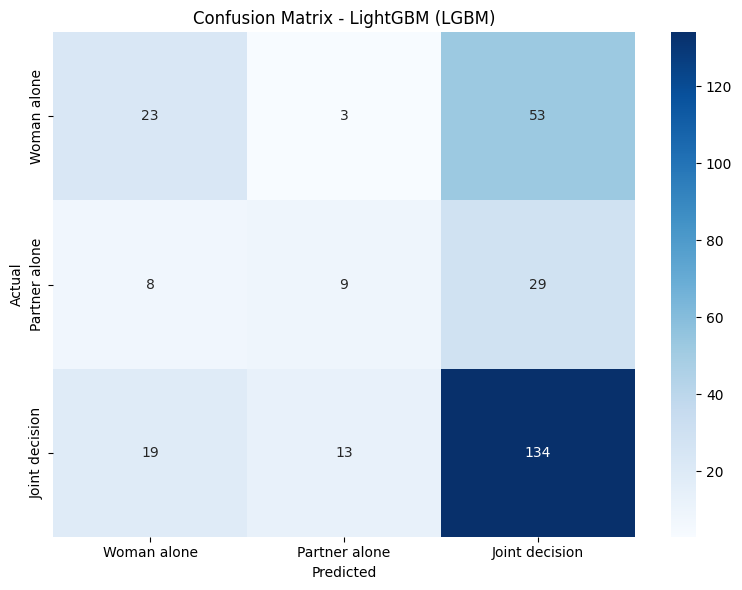

In [20]:
# ================================================================
# WHY FINAL TRAINING: After CV, we know which model is best
# Now we train that model on ALL training data (not just 90%)
# Then evaluate ONCE on untouched test set
#
# CRITICAL: Test set has been completely unused until NOW
# This is your TRUE, unbiased performance estimate
# ================================================================

print("\n" + "="*60)
print("FINAL TRAINING & TEST SET EVALUATION")
print("="*60)

# Find best model from CV
best_model_name = max(cv_results, key=lambda x: cv_results[x]['mean'])
print(f"Best model from CV: {best_model_name}")
print(f"Cross-validation F1: {cv_results[best_model_name]['mean']:.4f}")

# Get the best pipeline
best_pipeline = models[best_model_name]

# Train on FULL training set
print("\nTraining on full training set...")
best_pipeline.fit(X_train, y_train)

# Predict on TEST set (untouched until now!)
y_pred = best_pipeline.predict(X_test)

# Calculate final metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')
test_precision = precision_score(y_test, y_pred, average='weighted')
test_recall = recall_score(y_test, y_pred, average='weighted')

print("\n" + "="*50)
print("FINAL TEST SET PERFORMANCE (HONEST ESTIMATE)")
print("="*50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Woman alone', 'Partner alone', 'Joint decision']))

# Confusion Matrix
print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Woman alone', 'Partner alone', 'Joint decision'],
            yticklabels=['Woman alone', 'Partner alone', 'Joint decision'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()


SHAP ANALYSIS - Understanding Model Predictions
Using SHAP TreeExplainer for interpretation...

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (200, 62, 3)


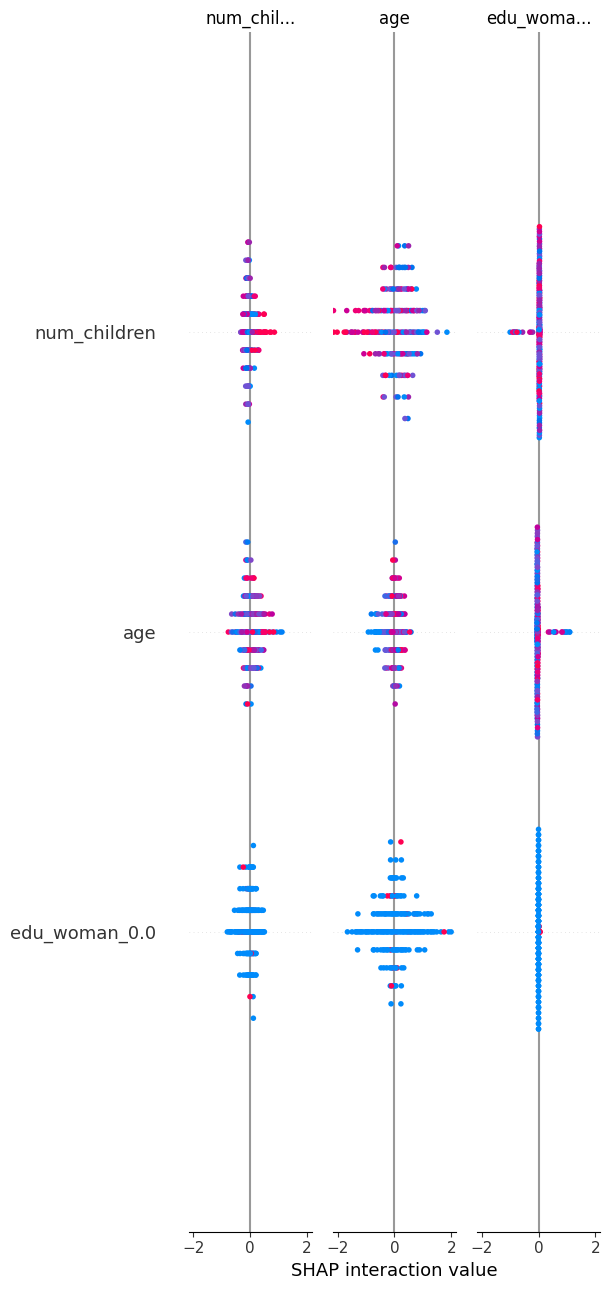

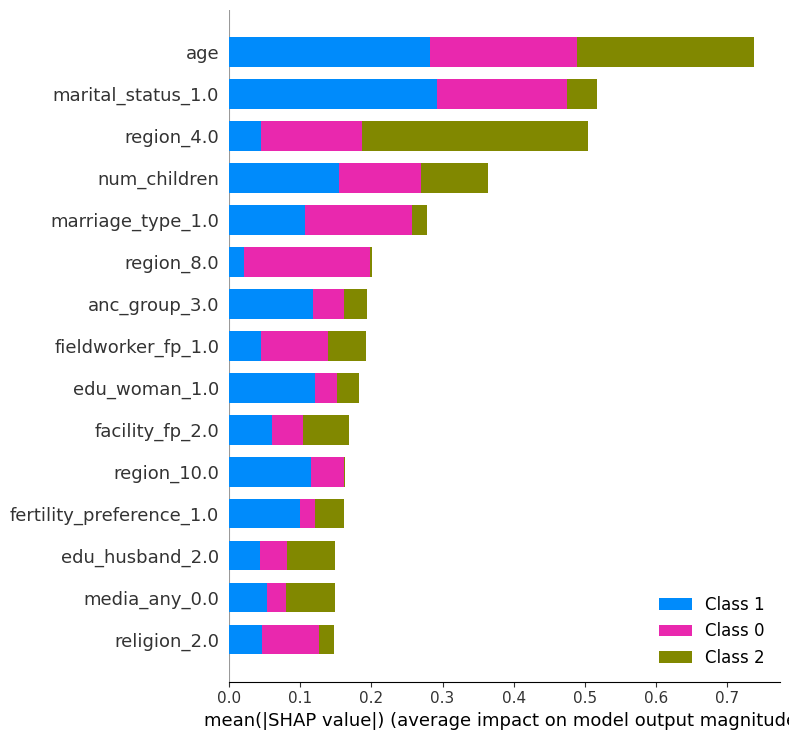

In [22]:
# ================================================================
# CORRECTED SHAP CODE FOR MULTICLASS
# ================================================================

print("\n" + "="*60)
print("SHAP ANALYSIS - Understanding Model Predictions")
print("="*60)

# Only run SHAP for tree-based models
if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM (LGBM)', 'Decision Tree']:
    
    print("Using SHAP TreeExplainer for interpretation...")
    
    # Fit preprocessor to get feature names
    preprocessor.fit(X_train)
    
    # Get transformed feature names
    num_features = NUMERICAL_FEATURES
    cat_features = preprocessor.named_transformers_['categorical'].get_feature_names_out(CATEGORICAL_FEATURES)
    feature_names = list(num_features) + list(cat_features)
    
    # Take a sample for SHAP (to avoid memory issues)
    X_sample = X_train.sample(min(200, len(X_train)))  # Reduced to 200 samples
    X_sample_processed = preprocessor.transform(X_sample)
    
    # Get the classifier from pipeline
    if USE_SMOTE:
        classifier = best_pipeline.named_steps['classifier']
    else:
        classifier = best_pipeline.named_steps['classifier']
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_sample_processed)
    
    # Check the structure of shap_values
    print(f"\nSHAP values type: {type(shap_values)}")
    
    if isinstance(shap_values, list):
        print(f"Number of classes: {len(shap_values)}")
        print(f"SHAP values shape per class: {shap_values[0].shape}")
        print(f"Features shape: {X_sample_processed.shape}")
        
        # For multiclass, shap_values is a list of arrays (one per class)
        # Plot for each class
        class_names = ['Woman alone (Class 0)', 'Partner alone (Class 1)', 'Joint decision (Class 2)']
        
        for i in range(len(shap_values)):
            print(f"\n--- SHAP Summary Plot - {class_names[i]} ---")
            print("Red = high feature value, Blue = low feature value")
            print("Points right of 0 = pushes prediction toward this class")
            print("Points left of 0 = pushes prediction away from this class")
            
            shap.summary_plot(
                shap_values[i], 
                X_sample_processed, 
                feature_names=feature_names,
                show=False,
                max_display=15  # Limit to top 15 features for clarity
            )
            plt.tight_layout()
            plt.show()
            
            # Bar plot for this class
            print(f"\n--- SHAP Bar Plot - {class_names[i]} (Feature Importance) ---")
            shap.summary_plot(
                shap_values[i], 
                X_sample_processed, 
                feature_names=feature_names,
                plot_type="bar",
                show=False,
                max_display=15
            )
            plt.tight_layout()
            plt.show()
    
    else:
        # Binary case (shap_values is a single array)
        print(f"SHAP values shape: {shap_values.shape}")
        
        shap.summary_plot(
            shap_values, 
            X_sample_processed, 
            feature_names=feature_names,
            show=False,
            max_display=15
        )
        plt.tight_layout()
        plt.show()
        
        shap.summary_plot(
            shap_values, 
            X_sample_processed, 
            feature_names=feature_names,
            plot_type="bar",
            show=False,
            max_display=15
        )
        plt.tight_layout()
        plt.show()

else:
    print(f"SHAP TreeExplainer not available for {best_model_name}")
    print("Skipping SHAP analysis - model is not tree-based")

In [23]:
# ================================================================
# WHY SAVE: So you can use the model later without retraining
#           Also saves results for your report/paper
# ================================================================

print("\n" + "="*60)
print("SAVING RESULTS AND MODEL")
print("="*60)

import joblib
import json
from datetime import datetime

# -----------------------------------------------------------------
# 13.1: Save the model
# -----------------------------------------------------------------
joblib.dump(best_pipeline, 'best_model.pkl')
print("✓ Model saved as 'best_model.pkl'")

# -----------------------------------------------------------------
# 13.2: Save preprocessor separately (for future predictions)
# -----------------------------------------------------------------
joblib.dump(preprocessor, 'preprocessor.pkl')
print("✓ Preprocessor saved as 'preprocessor.pkl'")

# -----------------------------------------------------------------
# 13.3: Save results as JSON (for report)
# -----------------------------------------------------------------
results = {
    'study_date': datetime.now().isoformat(),
    'best_model': best_model_name,
    'cv_performance': {
        'mean_f1': float(cv_results[best_model_name]['mean']),
        'std_f1': float(cv_results[best_model_name]['std'])
    },
    'test_performance': {
        'accuracy': float(test_accuracy),
        'f1_score': float(test_f1),
        'precision': float(test_precision),
        'recall': float(test_recall)
    },
    'confusion_matrix': cm.tolist(),
    'sample_size': len(X),
    'train_size': len(X_train),
    'test_size': len(X_test)
}

with open('model_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("✓ Results saved as 'model_results.json'")

# -----------------------------------------------------------------
# 13.4: Print final summary
# -----------------------------------------------------------------
print("\n" + "="*60)
print("PROJECT COMPLETE!")
print("="*60)
print(f"""
FINAL SUMMARY
-------------
Best Model: {best_model_name}
Cross-validation F1: {cv_results[best_model_name]['mean']:.4f} (±{cv_results[best_model_name]['std']:.4f})
Test Set F1: {test_f1:.4f}
Test Set Accuracy: {test_accuracy:.4f}

Files Created:
  - best_model.pkl      (use for predictions)
  - preprocessor.pkl    (use with model)
  - model_results.json  (for your report)

To load model later:
  import joblib
  model = joblib.load('best_model.pkl')
  predictions = model.predict(new_data)
""")


SAVING RESULTS AND MODEL
✓ Model saved as 'best_model.pkl'
✓ Preprocessor saved as 'preprocessor.pkl'
✓ Results saved as 'model_results.json'

PROJECT COMPLETE!

FINAL SUMMARY
-------------
Best Model: LightGBM (LGBM)
Cross-validation F1: 0.5157 (±0.0277)
Test Set F1: 0.5371
Test Set Accuracy: 0.5704

Files Created:
  - best_model.pkl      (use for predictions)
  - preprocessor.pkl    (use with model)
  - model_results.json  (for your report)

To load model later:
  import joblib
  model = joblib.load('best_model.pkl')
  predictions = model.predict(new_data)

